<a href="https://colab.research.google.com/github/whiterabbit077/ST554/blob/main/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title:** Homework #6  
**Class:** ST-554 Big Data  
**Date:** 3/11/2026  
**Author:** Anna Giczewska

#Part I - More Practice Querying a Database

**1. Connect to the database and list all tables**  

Cnnect to the SQLite database. Then use `pandas.read_sql()` to see all of the tables in the database.


In [ ]:
import os
import urllib.request
import sqlite3
import pandas as pd

DB_URL = "https://github.com/jknecht/baseball-archive-sqlite/releases/download/2022/lahman_1871-2022.sqlite"
DB_FILE = "lahman.sqlite"

# download the database if it is not already there
if not os.path.exists(DB_FILE):
    print("Downloading database file...")
    urllib.request.urlretrieve(DB_URL, DB_FILE)

# connect to the database
conn = sqlite3.connect(DB_FILE)

# look at the tables
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name
""", conn)

tables.head(20)

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


**2. Create a table of hall of fame pitchers with pitching totals**  
Use SQL to find players who are in the Hall of Fame and also appear in the Pitching table and provide pitching statistics.


In [ ]:
pitching_df = pd.read_sql("""
SELECT p.playerID,
       SUM(p.GS) AS GS,
       SUM(p.G) AS G,
       SUM(p.W) AS W,
       SUM(p.L) AS L,
       SUM(p.IPouts) AS IPouts,
       SUM(p.CG) AS CG,
       SUM(p.SHO) AS SHO,
       SUM(p.SV) AS SV
FROM Pitching p
JOIN HallOfFame h
    ON p.playerID = h.playerID
WHERE h.inducted = 'Y'
GROUP BY p.playerID
""", conn)

pitching_df.head()

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0


**3. Create a table of batting statistics for all of the hall of fame pitchers**  
Use SQL again to get batting totals for the same Hall of Fame pitchers.


In [ ]:
batting_df = pd.read_sql("""
SELECT b.playerID,
       SUM(b.AB) AS AB,
       SUM(b.R) AS R,
       SUM(b.H) AS H,
       SUM(b.HR) AS HR,
       SUM(b.RBI) AS RBI,
       SUM(b.BB) AS BB,
       SUM(b.SO) AS SO
FROM Batting b
JOIN HallOfFame h
    ON b.playerID = h.playerID
WHERE h.inducted = 'Y'
AND b.playerID IN (
    SELECT playerID
    FROM Pitching
)
GROUP BY b.playerID
""", conn)

batting_df.head()

,playerID,AB,R,H,HR,RBI,BB,SO
0,alexape01,1810,154,378,11,163,77,276
1,ansonca01,10281,1999,3435,97,2075,984,330
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,1147,102,243,6,116,75,143
4,blylebe01,451,19,59,0,25,5,193


**4. Join the previous two tables together by pitcher**  
Use `pd.merge()` to join the pitching totals table and the batting totals table using `playerID`.


In [ ]:
final_df = pd.merge(pitching_df, batting_df, on="playerID")

final_df.head()

,playerID,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25,5,193


**5. Close database connection**

In [ ]:
conn.close()

#test if connection was closed properly
try:
    pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
except Exception as e:
    print("It is closed now.")
    print(e)

It is closed now.
Cannot operate on a closed database.


#Part II - Messing with Classes

Design a Python class that encapsulates the simulation
of the sampling distribution of the slope estimator.

run_simulations() must be called first.


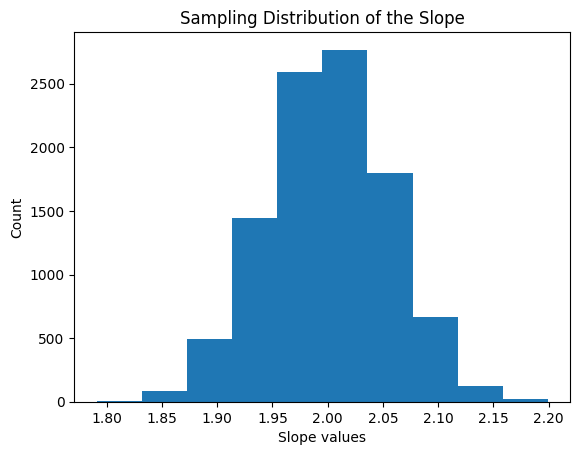

0.0704
[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng


class SLR_slope_simulator:

    # this starts the class and saves all of the values we need
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        # intercept in the regression model
        self.beta_0 = beta_0

        # true slope in the regression model
        self.beta_1 = beta_1

        # x values that stay fixed in every simulation
        self.x = x

        # standard deviation of the random error terms
        self.sigma = sigma

        # number of x values
        self.n = len(x)

        # random number generator with a seed so results can be repeated
        self.rng = default_rng(seed)

        # empty list at first, later this will store all simulated slopes
        self.slopes = []

    # this method makes one fake dataset using the regression model
    def generate_data(self):
        # generate random errors from a normal distribution
        errors = self.rng.normal(0, self.sigma, self.n)

        # use the model y = beta_0 + beta_1*x + error
        y = self.beta_0 + self.beta_1 * self.x + errors

        # return both x and y
        return self.x, y

    # this method calculates the slope estimate from x and y
    def fit_slope(self, x, y):
        # find the mean of x
        x_bar = np.mean(x)

        # find the mean of y
        y_bar = np.mean(y)

        # top part of the slope formula
        top = np.sum((x - x_bar) * (y - y_bar))

        # bottom part of the slope formula
        bottom = np.sum((x - x_bar) ** 2)

        # slope estimate
        slope = top / bottom

        return slope

    # this method runs the simulation many times
    def run_simulations(self, num_simulations):
        # make an empty list to store slope estimates
        slope_list = []

        # repeat the process num_simulations times
        for i in range(num_simulations):
            # generate one dataset
            x, y = self.generate_data()

            # find the slope for that dataset
            slope = self.fit_slope(x, y)

            # save the slope in the list
            slope_list.append(slope)

        # turn the list into a numpy array and save it
        self.slopes = np.array(slope_list)

    # this method plots a histogram of the simulated slopes
    def plot_sampling_distribution(self):
        # check if simulations have been run yet
        if len(self.slopes) == 0:
            print("run_simulations() must be called first.")
        else:
            # make a histogram of the slope values
            plt.hist(self.slopes)

            # label the graph
            plt.xlabel("Slope values")
            plt.ylabel("Count")
            plt.title("Sampling Distribution of the Slope")

            # show the graph
            plt.show()

    # this method finds probabilities from the simulated slopes
    def find_prob(self, value, sided):
        # check if simulations were run first
        if len(self.slopes) == 0:
            print("run_simulations() must be called first.")
            return None

        # probability slope is above the value
        if sided == "above":
            return np.mean(self.slopes > value)

        # probability slope is below the value
        elif sided == "below":
            return np.mean(self.slopes < value)

        # approximate two-sided probability
        elif sided == "two-sided":
            # find the middle of the simulated slopes
            middle = np.median(self.slopes)

            # if the value is above the middle, double the upper tail
            if value > middle:
                return 2 * np.mean(self.slopes > value)

            # otherwise double the lower tail
            else:
                return 2 * np.mean(self.slopes < value)

        # if the user types something wrong
        else:
            print("Pick 'above', 'below', or 'two-sided'")
            return None


# code below the class

# make the x values from 0 to 10 and repeat them 3 times
x = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)

# create the simulator object
# beta_0 = 12, beta_1 = 2, sigma = 1, seed = 10
sim = SLR_slope_simulator(12, 2, x, 1, 10)

# try plotting before simulations are run
# this should print an error message
sim.plot_sampling_distribution()

# run 10,000 simulations
sim.run_simulations(10000)

# plot the histogram after simulations
sim.plot_sampling_distribution()

# find the approximate two-sided probability for 2.1
print(sim.find_prob(2.1, "two-sided"))

# print all of the simulated slope values
print(sim.slopes)